# Feature Selection and Data Cleaning

This notebook performs a systematic cleaning and reduction of the clinical dataset. It transitions from the broad set of collected data to a specific, curated subset required for the predictive model. The process involves:

+ Feature Filtering: Using $\texttt{features\_set}$ to filter $\texttt{df\_eligible}$ down to only those variables that are designated as important for the study. This set of clinically relevant variables was provided by an expert, familiar with both the dataset and its medical context.
+ Identifying and removing duplicate information—specifically, dropping categorical genotype columns ($\texttt{rsXXX}$) in favor of their numeric equivalents ($\texttt{XXX\_n\_risk\_alleles}$), as the latter provide identical information but are better suited for neural network architectures.
+ Variance/Entropy Analysis: Computing the variance (for numeric variables) and Shannon entropy (for categorical variables) to quantify how much information each feature actually contributes. This step is critical for identifying "low-signal" features that might otherwise introduce noise into the model.
+ Preprocessing and Feature Transformation: Removing redundant or low‑information variables and converting categorical features into appropriate numerical formats to ensure compatibility with the modeling pipeline.

Datasets Generated:
+ $\texttt{df\_eligible\_reduced2}$: A cleaned dataframe containing only the selected features, ready for model training (before filling in the nan values).
+ $\texttt{df\_traits\_reduced2}$: A cleaned dataframe containing the metadata (trait name, definition, and units) for all variables included in the modeling dataset.

## Read the data

In [1]:
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path_data = "dataframes/df_eligible_VTE.csv"
df_eligible = pd.read_csv(path_data)

path_traits = "dataframes/df_traits_VTE.csv"
df_traits = pd.read_csv(path_traits)

path_features = "data/features_set.csv"
df_traits_reduced = pd.read_csv(path_features)

trait_to_def = dict(zip(df_traits["trait"], df_traits["definition"]))

## Adapt the dataset

### Solve $\texttt{.csv}$ format

First, let's correct some rows from the new reduced dataset that give some problems with their $\texttt{.csv}$ format.

In [3]:
problem_rows = df_traits_reduced[df_traits_reduced["trait"].str.contains(",")]
problem_rows

,trait,definition,units


In [4]:
fixed_rows = pd.DataFrame([
    {   "trait": "menopausal_status",
        "definition": "Whether women are pre-, peri- or post-menopausal",
        "units": "NA"    },
    {   "trait": "bmi_category",
        "definition": "Whether patient has under-, normal, over-weight or obesity according to BMI",
        "units": "NA"    },
    {   "trait": "grade_histological_differentiation",
        "definition": "Grade of tumor histological differentiation (well, moderately or poorly differentiated)",
        "units": "NA"    }
])

df_traits_reduced = df_traits_reduced.drop(index=problem_rows.index).copy()
df_traits_reduced = pd.concat([df_traits_reduced, fixed_rows], ignore_index=True)

### Keep columns from $\texttt{df\_reduced}$

In [5]:
# We only keep, from df_eligible, the important columns (on df_traits_reduced)
traits = df_traits_reduced["trait"].unique()
cols_to_keep = [col for col in df_eligible.columns if col in traits]

df_eligible_reduced = df_eligible.copy()
df_eligible_reduced = df_eligible_reduced[cols_to_keep]

df_eligible_reduced.columns

# dropped_traits = [t for t in traits if t not in df_eligible.columns]
# dropped_traits

Index(['id', 'informed_consent', 'eligible', 'sex', 'menopausal_status',
       'date_cancer_dx', 'age_cancer_dx', 'bmi', 'bmi_category',
       'performance_status', 'tobacco_use', 'chronic_cardiac_insufficiency',
       'copd', 'renal_insufficiency', 'arterial_hypertension',
       'diabetes_mellitus', 'dyslipidemia', 'hormone_therapy', 'previous_vte',
       'previous_ate', 'venous_insufficiency', 'family_background_vte',
       'primary_tumor', 'grade_histological_differentiation', 'pTNM_stage',
       'tumor_surgically_removed', 'catheter_device',
       'vte_concomitant_cancer_dx', 'date_vte_concomitant_cancer_dx',
       'date_blood_test', 'VTE', 'date_VTE', 'patient_status',
       'date_end_study', 'date_death', 'rs11696364_n_risk_alleles',
       'rs169713_n_risk_alleles', 'rs4524_n_risk_alleles',
       'rs6003_n_risk_alleles', 'rs2227631_n_risk_alleles',
       'rs268_n_risk_alleles', 'rs5110_n_risk_alleles',
       'rs6025_n_risk_alleles', 'rs2232698_n_risk_alleles', 'rs45

In [6]:
# Shape

n_rows, n_columns = df_eligible_reduced.shape
print("Rows: ", n_rows)
print("Columns: ", n_columns)

Rows:  395
Columns:  59


After defining our new dataframe $\texttt{df\_eligible\_reduced}$, let's take a look at a single patient's data:

In [7]:
# For patient-confidentiallity, this will not be shown

# check one patient - id in {1, 432} (some of them will be empty because we have dropped some rows)
# patient_id = 1

# row = df_eligible_reduced.loc[df_eligible_reduced["id"] == patient_id].squeeze()
# for col, val in row.items():
#     print(f"{col}: {val}")

### Consistent variables

-----
It seems that the risk alleles variables are duplicated. We should verify wether each SNP genotype column $\texttt{rsXXX}$ is consistent with its own corresponding risk-allele count column $\texttt{XXX\_n\_risk\_alleles}$. 

In [8]:
snps = [
    "rs11696364", "rs169713", "rs4524", "rs6003", "rs2227631",
    "rs268", "rs5110", "rs6025", "rs2232698"
]

for snp in snps:
    geno_col = snp
    risk_col = f"{snp}_n_risk_alleles"
    if geno_col in df_eligible_reduced.columns and risk_col in df_eligible_reduced.columns:
        print(f"\nChecking {snp}:")
        print(df_eligible_reduced[[geno_col, risk_col]].drop_duplicates())


Checking rs11696364:
   rs11696364  rs11696364_n_risk_alleles
0          CC                        0.0
1          AC                        1.0
4         NaN                        NaN
13         AA                        2.0

Checking rs169713:
   rs169713  rs169713_n_risk_alleles
0        CT                      1.0
2        TT                      0.0
4       NaN                      NaN
13       CC                      2.0

Checking rs4524:
  rs4524  rs4524_n_risk_alleles
0     CC                    0.0
1     CT                    1.0
3     TT                    2.0
4    NaN                    NaN

Checking rs6003:
   rs6003  rs6003_n_risk_alleles
0      TT                    2.0
4     NaN                    NaN
7      CT                    1.0
29     CC                    0.0

Checking rs2227631:
  rs2227631  rs2227631_n_risk_alleles
0        AA                       0.0
4       NaN                       NaN
7        GG                       2.0
8        AG                       

Yes, in fact, both columns give exactly the same information.

-----
Let's do the same check with the columns
+ ($\texttt{sex}$, $\texttt{menopausal\_status}$)
+ ($\texttt{primary\_tumor}$, $\texttt{tumor\_type\_risk}$)
+ ($\texttt{bmi}$, $\texttt{bmi\_category}$)

In [9]:
from utils import freq_table_pair

table_sex_meno = freq_table_pair(df_eligible_reduced, "sex", "menopausal_status")
table_sex_meno

Freq      %
VTE sex   menopausal_status             
No  Man   Man                 179  60.47
    Woman Post-menopausal      98  33.11
          Pre-menopausal       12   4.05
          Peri-menopausal       4   1.35
          NaN                   3   1.01
Yes Man   Man                  50  52.63
    Woman Post-menopausal      42  44.21
          Pre-menopausal        2   2.11
          Peri-menopausal       1   1.05

In [10]:
table_tumor_risk = freq_table_pair(df_eligible_reduced, "primary_tumor", "tumor_type_risk")
table_tumor_risk

Freq      %
VTE primary_tumor tumor_type_risk             
No  Colorectal    LR                 87  29.39
    Pancreatic    VHR                70  23.65
    NSCLC         HR                 62  20.95
    Gastric       VHR                37  12.50
    Bile duct     LR                 24   8.11
    Oesophageal   VHR                11   3.72
    Brain         VHR                 4   1.35
    NaN           NaN                 1   0.34
Yes Pancreatic    VHR                42  44.21
    Colorectal    LR                 16  16.84
    Bile duct     LR                 13  13.68
    NSCLC         HR                 13  13.68
    Gastric       VHR                 8   8.42
    Oesophageal   VHR                 3   3.16

This means that, later on, we will not look at the correlation between these pairs of variables. Also, the $\texttt{primary\_tumor}$ column gives us more information than the $\texttt{tumor\_type\_risk}$ one.

### Preprocessing 1

Regarding both columns $\texttt{rsXXX}$ and $\texttt{XXX\_n\_risk\_alleles}$, we remove the letter‑based genotype columns and keep only the numeric risk‑allele columns, which are cleaner, model‑friendly, and fully equivalent. Also, remove their corresponding traits from $\texttt{df\_traits\_reduced}$.

In [11]:
alleles_drop = [
    "rs11696364", "rs169713", "rs2232698", "rs268", "rs4524",
    "rs5110", "rs6003", "rs6025", "rs2227631", "rs5985"
]

df_eligible_reduced = df_eligible_reduced.drop(columns=alleles_drop, errors="ignore")

df_traits_reduced2 = df_traits_reduced.copy()
df_traits_reduced2 = df_traits_reduced2[
    ~df_traits_reduced2["trait"].isin(alleles_drop)
]

## Variances of the variables

In this section, we study the variability of each feature in the dataset. The goal is to identify variables that contribute little or no information because they show very low variance (in numeric features) or very low entropy (in categorical features).

In medical datasets with a limited number of patients, this step is especially important, because we can have variables with almost no variation (diseases that almost nobody has), or categories where nearly all patients belong to the same group (which provide minimal predictive value and often introduce noise rather than signal).

+ Variance of Numeric Variables: we compute the statistical variance, defined as:
$$
Var(X)=\frac{1}{n-1}\sum_{i=1}^n(x_i-\bar{x})^2
$$

+ Entropy of Categorical Variables: variance is not meaningful. Instead, we measure Shannon entropy, which quantifies how “spread out” the categories are:
$$
H=-\sum p_i \cdot log(p_i)
$$

### Numerical columns

In [12]:
# keep numerical columns
numeric_cols = df_eligible_reduced.select_dtypes(include=["number"]).columns
# discard the datetime columns
numeric_no_date = [col for col in numeric_cols if "date" not in col.lower()]

variances = df_eligible_reduced[numeric_no_date].var().sort_values(ascending=True).round(2)

df_num_variances = pd.DataFrame({
    "variance": variances.values,
    "variable": variances.index,
    "descripcion": [trait_to_def.get(col, "—") for col in variances.index]
})

# sort the variances
df_num_variances = df_num_variances.sort_values(by="variance", ascending=True)
pd.set_option("display.max_colwidth", None)
df_num_variances

,variance,variable,descripcion
0,0.03,rs2232698_n_risk_alleles,Number of risk alleles in SNP rs2232698
1,0.03,rs6025_n_risk_alleles,Number of risk alleles in SNP rs6025
2,0.03,rs268_n_risk_alleles,Number of risk alleles in SNP rs268
3,0.16,rs6003_n_risk_alleles,Number of risk alleles in SNP rs6003
4,0.16,rs5110_n_risk_alleles,Number of risk alleles in SNP rs5110
5,0.19,rs11696364_n_risk_alleles,Number of risk alleles in SNP rs11696364
6,0.34,rs5985_n_risk_alleles,Number of risk alleles in SNP rs5985
7,0.38,performance_status,ECOG performance status at beginning of chemotherapy
8,0.39,rs169713_n_risk_alleles,Number of risk alleles in SNP rs169713
9,0.39,rs4524_n_risk_alleles,Number of risk alleles in SNP rs4524


### Categorical columns

In [13]:
categorical_cols = df_eligible_reduced.select_dtypes(include=["object", "category"]).columns

# Exclude datetime columns
cat_no_date = [col for col in categorical_cols if "date" not in col.lower()]

# Distribution of each column
for col in cat_no_date:
    print(f"\n=== {col} ===")
    value_counts = df_eligible_reduced[col].value_counts(dropna=False)
    for value, count in value_counts.items():
        print(f"{value} -> {count}")


=== informed_consent ===
Yes -> 395

=== eligible ===
Yes -> 395

=== sex ===
Man -> 233
Woman -> 162

=== menopausal_status ===
Man -> 233
Post-menopausal -> 140
Pre-menopausal -> 14
Peri-menopausal -> 5
nan -> 3

=== bmi_category ===
Normal -> 199
Overweight -> 131
Obese -> 44
Underweight -> 20
nan -> 1

=== tobacco_use ===
Former smoker -> 176
Never has smoked -> 128
Active smoker -> 78
nan -> 13

=== chronic_cardiac_insufficiency ===
No -> 389
Yes -> 5
nan -> 1

=== copd ===
No -> 347
Yes -> 47
nan -> 1

=== renal_insufficiency ===
No -> 385
Yes -> 9
nan -> 1

=== arterial_hypertension ===
No -> 222
Yes -> 172
nan -> 1

=== diabetes_mellitus ===
No -> 300
Yes -> 94
nan -> 1

=== dyslipidemia ===
No -> 254
Yes -> 140
nan -> 1

=== hormone_therapy ===
No -> 387
Yes -> 7
nan -> 1

=== previous_vte ===
No -> 385
Yes -> 7
nan -> 3

=== previous_ate ===
No -> 360
Yes -> 35

=== venous_insufficiency ===
No -> 320
Yes -> 45
nan -> 30

=== family_background_vte ===
No -> 244
nan -> 132
Yes

#### Shannon entropy for categorical variables

In [14]:
# If the Shannon entropy is 0, it means that all the observations are the same, so they give 0 information
# If the Shannon entropy is high, then there are well-distributed categories (informative variable)

from utils import categorical_entropy

entropies = {}

for col in cat_no_date:
    entropies[col] = categorical_entropy(df_eligible_reduced[col])

df_cat_entropy = pd.DataFrame({
    "variable": list(entropies.keys()),
    "entropy": list(entropies.values()),
    "descripcion": [trait_to_def.get(col, "—") for col in entropies.keys()]
})

df_cat_entropy = df_cat_entropy[df_cat_entropy["entropy"] > 0]

df_cat_entropy = df_cat_entropy.sort_values(by="entropy", ascending=True)

pd.set_option("display.max_rows", None)
df_cat_entropy

,variable,entropy,descripcion
6,chronic_cardiac_insufficiency,0.123379,Whether patient suffers chronic cardiac insufficiency
12,hormone_therapy,0.153869,Whether patient is being treated with hormone therapy
8,renal_insufficiency,0.182204,Whether patient suffers renal insufficiency
13,previous_vte,0.192642,Whether patient had VTE at least six months prior to cancer diagnosis
26,VTE_recurrence,0.280904,Whether patient suffered VTE recurrence along 12 months of follow-up
21,vte_concomitant_cancer_dx,0.340373,Was VTE diagnosed at the same time or following to cancer diagnosis?
14,previous_ate,0.431805,Whether patient had ATE prior to cancer diagnosis
7,copd,0.551465,Whether patient suffers chronic obstructive pulmonary disease (COPD)
10,diabetes_mellitus,0.816147,Whether patient suffers diabetes mellitus
22,VTE,0.873470,Venous thromboembolism observed along 12 months of follow-up (primary endpoint of study)


## Frequency table for VTE

In [15]:
df_freq = df_eligible_reduced.copy()

print("Final columns:", len(df_freq.columns))

Final columns: 49


In [16]:
# For patient-confidentiallity, this will not be shown

# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)
# df_freq.head(2)

### VTE alone

In [17]:
freq_table = pd.DataFrame({
    "Freq": df_freq["VTE"].value_counts(dropna=False),
    "%": (df_freq["VTE"].value_counts(normalize=True, dropna=False) * 100).round(2)
})

freq_table

,Freq,%
VTE,,
No,296,74.94
Yes,95,24.05
NaN,4,1.01


### VTE with another variable

In [18]:
from utils import freq_table

cols_freq = [
    col for col in df_freq.columns
    if col not in {"VTE", "id", "informed_consent", "eligible", "bmi", "age_cancer_dx", "age" } and not col.lower().startswith("date")
]
cols_freq

['sex',
 'menopausal_status',
 'bmi_category',
 'performance_status',
 'tobacco_use',
 'chronic_cardiac_insufficiency',
 'copd',
 'renal_insufficiency',
 'arterial_hypertension',
 'diabetes_mellitus',
 'dyslipidemia',
 'hormone_therapy',
 'previous_vte',
 'previous_ate',
 'venous_insufficiency',
 'family_background_vte',
 'primary_tumor',
 'grade_histological_differentiation',
 'pTNM_stage',
 'tumor_surgically_removed',
 'catheter_device',
 'vte_concomitant_cancer_dx',
 'patient_status',
 'rs11696364_n_risk_alleles',
 'rs169713_n_risk_alleles',
 'rs4524_n_risk_alleles',
 'rs6003_n_risk_alleles',
 'rs2227631_n_risk_alleles',
 'rs268_n_risk_alleles',
 'rs5110_n_risk_alleles',
 'rs6025_n_risk_alleles',
 'rs2232698_n_risk_alleles',
 'tumor_type_risk',
 'hospital',
 'rs5985_n_risk_alleles',
 'VTE_recurrence']

In [19]:
table = freq_table(df_freq, cols_freq)

table["sex"]

Freq      %
VTE sex               
No  Man     179  60.47
    Woman   117  39.53
Yes Man      50  52.63
    Woman    45  47.37

### Frequency VTE-variable

Let's try to rank all the variables in $\texttt{cols\_freq}$ by how strongly they are associated with VTE, using the frequency tables. What this means is that we are looking for a great difference in frequences between $\texttt{VTE}$=1 and $\texttt{VTE}$=0.

The idea is:
+ For each variable, we compute the distribution of its categories inside each VTE group
+ Measure how different the distributions are
+ Variables where the distributions are similar $\rightarrow$ weak relation
+ Variables where the distributions are very different $\rightarrow$ strong relation

A simple and effective metric is the sum of absolute differences between category percentages in $\texttt{VTE}$=1 and $\texttt{VTE}$=0, this gives us a single numeric score per variable, sortable ascending or descending.

In [20]:
from utils import association_score

# Compute score for each variable
scores = {
    col: association_score(table[col])
    for col in cols_freq
}

df_ranked = (
    pd.DataFrame(scores.items(), columns=["variable", "association_score"])
      .sort_values("association_score", ascending=False)
)

df_ranked

,variable,association_score
22,patient_status,64.23
21,vte_concomitant_cancer_dx,52.64
16,primary_tumor,52.28
33,hospital,42.74
3,performance_status,42.42
18,pTNM_stage,40.83
17,grade_histological_differentiation,30.10
32,tumor_type_risk,29.15
25,rs4524_n_risk_alleles,25.56
35,VTE_recurrence,25.26


Thanks to this table, we can see that, apparently, some variables could be more related to VTE than others, which could give away their higher significance in a prediction model.

## Correlation matrix

The goal of this section is to build a correlation matrix that captures how strongly each pair of variables in the dataset is related. This is a crucial step before modeling because:

+ Highly correlated variables may introduce redundancy
+ Some variables may encode the same information in different forms
+ Mixed datasets (numeric + categorical) require different correlation measures
+ Understanding the dependency structure helps with feature selection, interpretability, and model stability

However, our dataset contains multiple data types (numeric, categorical) and when computing correlations between them, we can encounter mixed pairs. This is why a single correlation measure (like Pearson) is not appropriate for all of them. Therefore, before computing correlations, we have a look at all the different types of columns we have, so we can properly define a good correlation function between them.

Also, we can take advantage of this section and also drop variables that don't affect or are difficult to treat for modelling, and that, at the same time, we don't care about their correlation between other variables.

In [21]:
from utils import table_types_unique

cols_to_drop = [
    "informed_consent", "id", "eligible", "date_cancer_dx", "date_death", 
    "date_VTE", "date_end_study", "date_blood_test", "date_vte_concomitant_cancer_dx"
]

df_eligible_reduced2 = df_eligible_reduced.drop(columns=cols_to_drop, errors="ignore")
df_traits_reduced2 = df_traits_reduced2[
    ~df_traits_reduced2["trait"].isin(cols_to_drop)
]

table = table_types_unique(df_eligible_reduced2)
table

,column,type,distinct_values
0,sex,categorical,2
1,menopausal_status,categorical,4
2,age_cancer_dx,numeric,53
3,bmi,numeric,313
4,bmi_category,categorical,4
5,performance_status,numeric,3
6,tobacco_use,categorical,3
7,chronic_cardiac_insufficiency,categorical,2
8,copd,categorical,2
9,renal_insufficiency,categorical,2


### Building the matrix

In [22]:
from utils import numeric_corr_matrix, cramers_v, correlation_ratio, mixed_corr_matrix

corr_mixed = mixed_corr_matrix(df_eligible_reduced2)

In [23]:
# Blank diagonal
np.fill_diagonal(corr_mixed.values, np.nan)

# Forbidden pairs (too correlated) -> also blank to not distract us with the contrast
forbidden_pairs = [
    ("sex", "menopausal_status"),
    ("menopausal_status", "sex"),
    ("primary_tumor", "tumor_type_risk"),
    ("tumor_type_risk", "primary_tumor"),
    ("bmi", "bmi_category"),
    ("bmi_category", "bmi")
]

for a, b in forbidden_pairs:
    if a in corr_mixed.index and b in corr_mixed.columns:
        corr_mixed.loc[a, b] = np.nan
    if b in corr_mixed.index and a in corr_mixed.columns:
        corr_mixed.loc[b, a] = np.nan

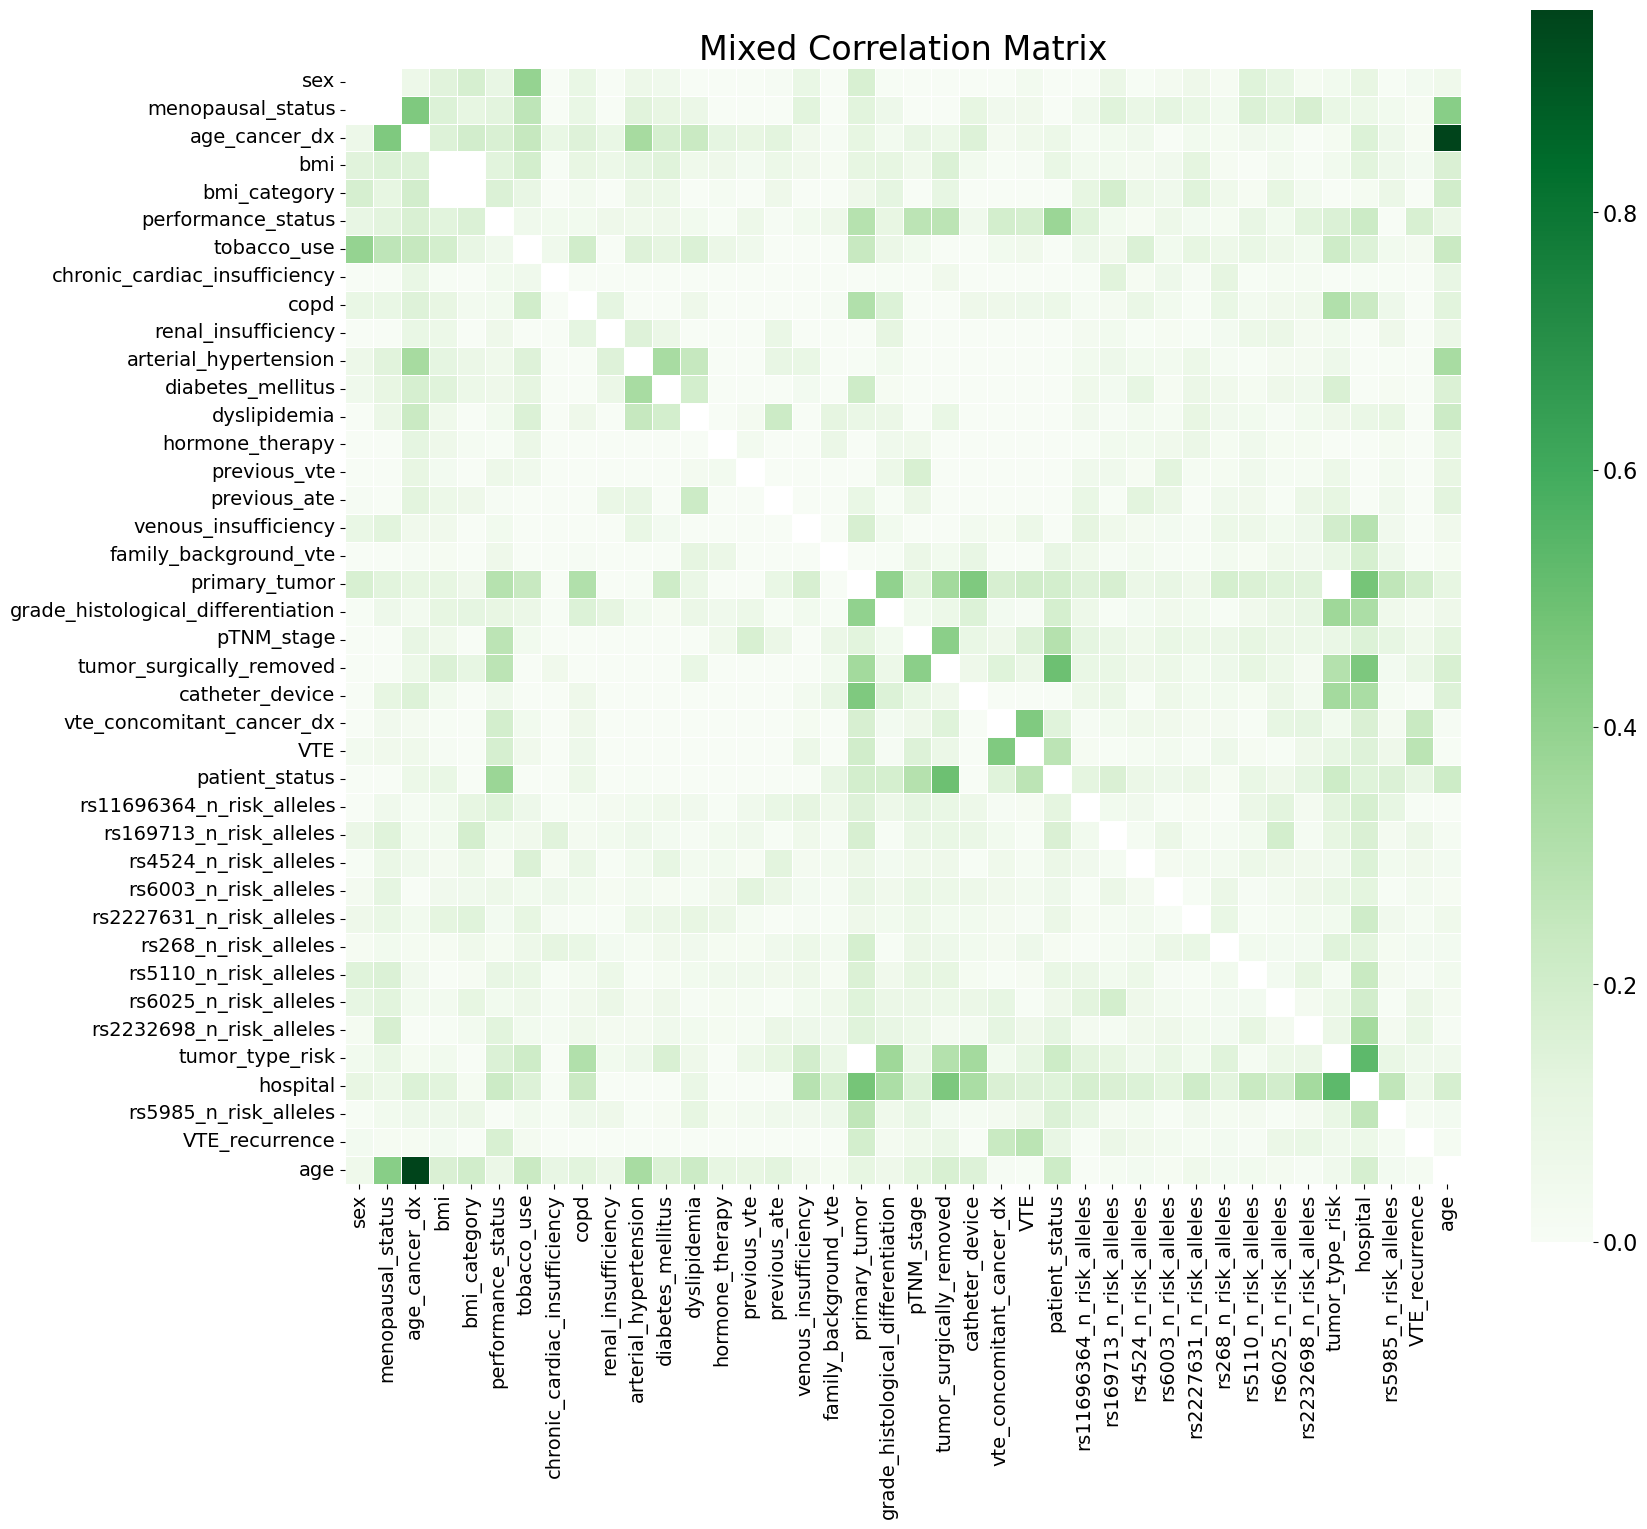

In [24]:
plt.figure(figsize=(18, 16))

ax=sns.heatmap(
    corr_mixed,
    cmap="Greens",     # from white to dark green
    vmin = corr_mixed.min().min(),
    vmax = corr_mixed.max().max(),
    annot=False,
    square=True,
    linewidths=0.5,
    linecolor="white",
    mask=corr_mixed.isna()   # NaN -> also white
)

plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)

plt.title("Mixed Correlation Matrix", fontsize=24)

plt.savefig(
    "images/correlation_matrix_1.png",
    dpi=300,          # high resolution
    bbox_inches="tight"
)

plt.show()

Looking at this map of the correlation matrix, for modelling purposes and final dataset (before filling in the nan values) it's decided to drop the following variables:
+ $\texttt{hospital}$
+ $\texttt{menopausal\_status}$ - it can be given by sex and age
+ $\texttt{bmi\_category}$ - we keep $\texttt{bmi}$ because it's numerical
+ $\texttt{tumor\_type\_risk}$ - we keep $\texttt{primary\_tumor}$, because it's implicit and has more categories
+ $\texttt{age}$ - we keep $\texttt{age\_cancer\_dx}$

Also, $\texttt{pTNM\_stage}$ is labeled as categorical, but for numerical purposes, it's going to be converted numbers: I $\rightarrow$ 1, II $\rightarrow$ 2, III $\rightarrow$ 3, IV $\rightarrow$ 4. And every Y/N variable must be turned into 1/0.

Finally, we'll apply one-hot-encoding to the rest of categorical variables.

## More preprocessing

### Drop variables

Apart from the columns that were just mentioned, it's also decided to drop $\texttt{patient\_status}$ because of their insignificance to the problem we are trying to predict:

In [25]:
trait = "patient_status"

# Get definition from df_traits_reduced2
definition = df_traits_reduced2.loc[
    df_traits_reduced2["trait"] == trait, "definition"
].iloc[0]

print(f"Definition of {trait}:\n{definition}\n")

# 2. Get distinct values from df_eligible_reduced2
distinct_vals = df_eligible_reduced2[trait].unique()

print(f"Distinct values in df_eligible_reduced2[{trait}]:\n{distinct_vals}")

Definition of patient_status:
Patient status at the end of follow-up

Distinct values in df_eligible_reduced2[patient_status]:
['Alive without tumour disease' 'Alive with tumour disease'
 'Dead with tumour disease' 'Dead without tumour disease' nan]


In [26]:
cols_to_drop = [
    "hospital",
    "menopausal_status",
    "bmi_category",
    "tumor_type_risk",
    "age",
    "patient_status"
]

df_eligible_reduced2 = df_eligible_reduced2.drop(columns=cols_to_drop, errors="ignore")
df_traits_reduced2 = df_traits_reduced2[
    ~df_traits_reduced2["trait"].isin(cols_to_drop)
]

### $\texttt{pTNM\_stage}$

In [27]:
# "pTNM_stage" is converted into numbers: I -> 1, II -> 2, III -> 3, IV -> 4

mapping = {"I": 1, "II": 2, "III": 3, "IV": 4}
df_eligible_reduced2["pTNM_stage_num"] = df_eligible_reduced2["pTNM_stage"].map(mapping)

df_eligible_reduced2 = df_eligible_reduced2.drop(columns=["pTNM_stage"])

### Y/N columns

In [28]:
# Every Y/N variable is turned into 1/0.

yes_no_cols = []

for col in df_eligible_reduced2.columns:
    # Get unique values excluding NaN
    vals = df_eligible_reduced2[col].dropna().unique()
    # Normalize to lowercase strings
    vals_norm = {str(v).strip().lower() for v in vals}
    # Check if the set is exactly {"yes", "no"} or a subset (e.g., only "no")
    if vals_norm.issubset({"yes", "no"}) and len(vals_norm) > 0:
        yes_no_cols.append(col)

yes_no_cols

['chronic_cardiac_insufficiency',
 'copd',
 'renal_insufficiency',
 'arterial_hypertension',
 'diabetes_mellitus',
 'dyslipidemia',
 'hormone_therapy',
 'previous_vte',
 'previous_ate',
 'venous_insufficiency',
 'family_background_vte',
 'tumor_surgically_removed',
 'catheter_device',
 'vte_concomitant_cancer_dx',
 'VTE',
 'VTE_recurrence']

In [29]:
mapping = {"Yes": 1, "No": 0}

for col in yes_no_cols:
    df_eligible_reduced2[f"{col}_num"] = df_eligible_reduced2[col].map(mapping)

df_eligible_reduced2 = df_eligible_reduced2.drop(columns=yes_no_cols)

In [30]:
# Sex variable: M/W is now 1/0

mapping = {"Man": 0, "Woman": 1}
df_eligible_reduced2["sex_num"] = df_eligible_reduced2["sex"].map(mapping)

df_eligible_reduced2 = df_eligible_reduced2.drop(columns=["sex"])

### One-hot-encoding

In [31]:
table = table_types_unique(df_eligible_reduced2)
table

,column,type,distinct_values
0,age_cancer_dx,numeric,53
1,bmi,numeric,313
2,performance_status,numeric,3
3,tobacco_use,categorical,3
4,primary_tumor,categorical,7
5,grade_histological_differentiation,numeric,3
6,rs11696364_n_risk_alleles,numeric,3
7,rs169713_n_risk_alleles,numeric,3
8,rs4524_n_risk_alleles,numeric,3
9,rs6003_n_risk_alleles,numeric,3


Only two variables require encoding, which is perfectly fine because it keeps the dimensionality low and avoids introducing unnecessary complexity.

In [32]:
# one hot encoding for "tobacco_use" and "primary_tumor"
{
    "tobacco_use": df_eligible_reduced2["tobacco_use"].unique(),
    "primary_tumor": df_eligible_reduced2["primary_tumor"].unique()
}

{'tobacco_use': array(['Former smoker', 'Active smoker', 'Never has smoked', nan],
       dtype=object),
 'primary_tumor': array(['Pancreatic', 'Bile duct', 'Colorectal', 'Gastric', 'NSCLC',
        'Oesophageal', nan, 'Brain'], dtype=object)}

In [33]:
df_eligible_reduced2 = pd.get_dummies(
    df_eligible_reduced2,
    columns=["tobacco_use", "primary_tumor"],
    prefix=["tobacco_use", "primary_tumor"],
    drop_first=False, 
    dtype=int
)

# For patient-confidentiallity, this will not be shown
# df_eligible_reduced2.head()

Now we need to change $\texttt{df\_traits\_reduced2}$, because the variables of $\texttt{tobacco\_use}$ and $\texttt{primary\_tumor}$ are no longer there.

In [34]:
new_tobacco_cols = [c for c in df_eligible_reduced2.columns if c.startswith("tobacco_use_")]
new_primary_cols = [c for c in df_eligible_reduced2.columns if c.startswith("primary_tumor_")]

df_traits_reduced2 = df_traits_reduced2[
    ~df_traits_reduced2["trait"].isin(["tobacco_use", "primary_tumor"])
]

rows = []

for col in new_tobacco_cols:
    rows.append({
        "trait": col,
        "definition": "One-hot encoded category of tobacco_use",
        "units": "binary (0/1)"
    })
for col in new_primary_cols:
    rows.append({
        "trait": col,
        "definition": "One-hot encoded category of primary_tumor",
        "units": "binary (0/1)"
    })

df_new_traits = pd.DataFrame(rows)
df_new_traits

,trait,definition,units
0,tobacco_use_Active smoker,One-hot encoded category of tobacco_use,binary (0/1)
1,tobacco_use_Former smoker,One-hot encoded category of tobacco_use,binary (0/1)
2,tobacco_use_Never has smoked,One-hot encoded category of tobacco_use,binary (0/1)
3,primary_tumor_Bile duct,One-hot encoded category of primary_tumor,binary (0/1)
4,primary_tumor_Brain,One-hot encoded category of primary_tumor,binary (0/1)
5,primary_tumor_Colorectal,One-hot encoded category of primary_tumor,binary (0/1)
6,primary_tumor_Gastric,One-hot encoded category of primary_tumor,binary (0/1)
7,primary_tumor_NSCLC,One-hot encoded category of primary_tumor,binary (0/1)
8,primary_tumor_Oesophageal,One-hot encoded category of primary_tumor,binary (0/1)
9,primary_tumor_Pancreatic,One-hot encoded category of primary_tumor,binary (0/1)


In [35]:
df_traits_reduced2 = pd.concat([df_traits_reduced2, df_new_traits], ignore_index=True)

## Correlation matrix 2

In [36]:
from utils import mixed_corr_matrix

df_eligible_reduced2 = df_eligible_reduced2.rename(columns=lambda c: c[:-4] if c.endswith("_num") else c)
corr_mixed = mixed_corr_matrix(df_eligible_reduced2)

# Blank diagonal
np.fill_diagonal(corr_mixed.values, np.nan)

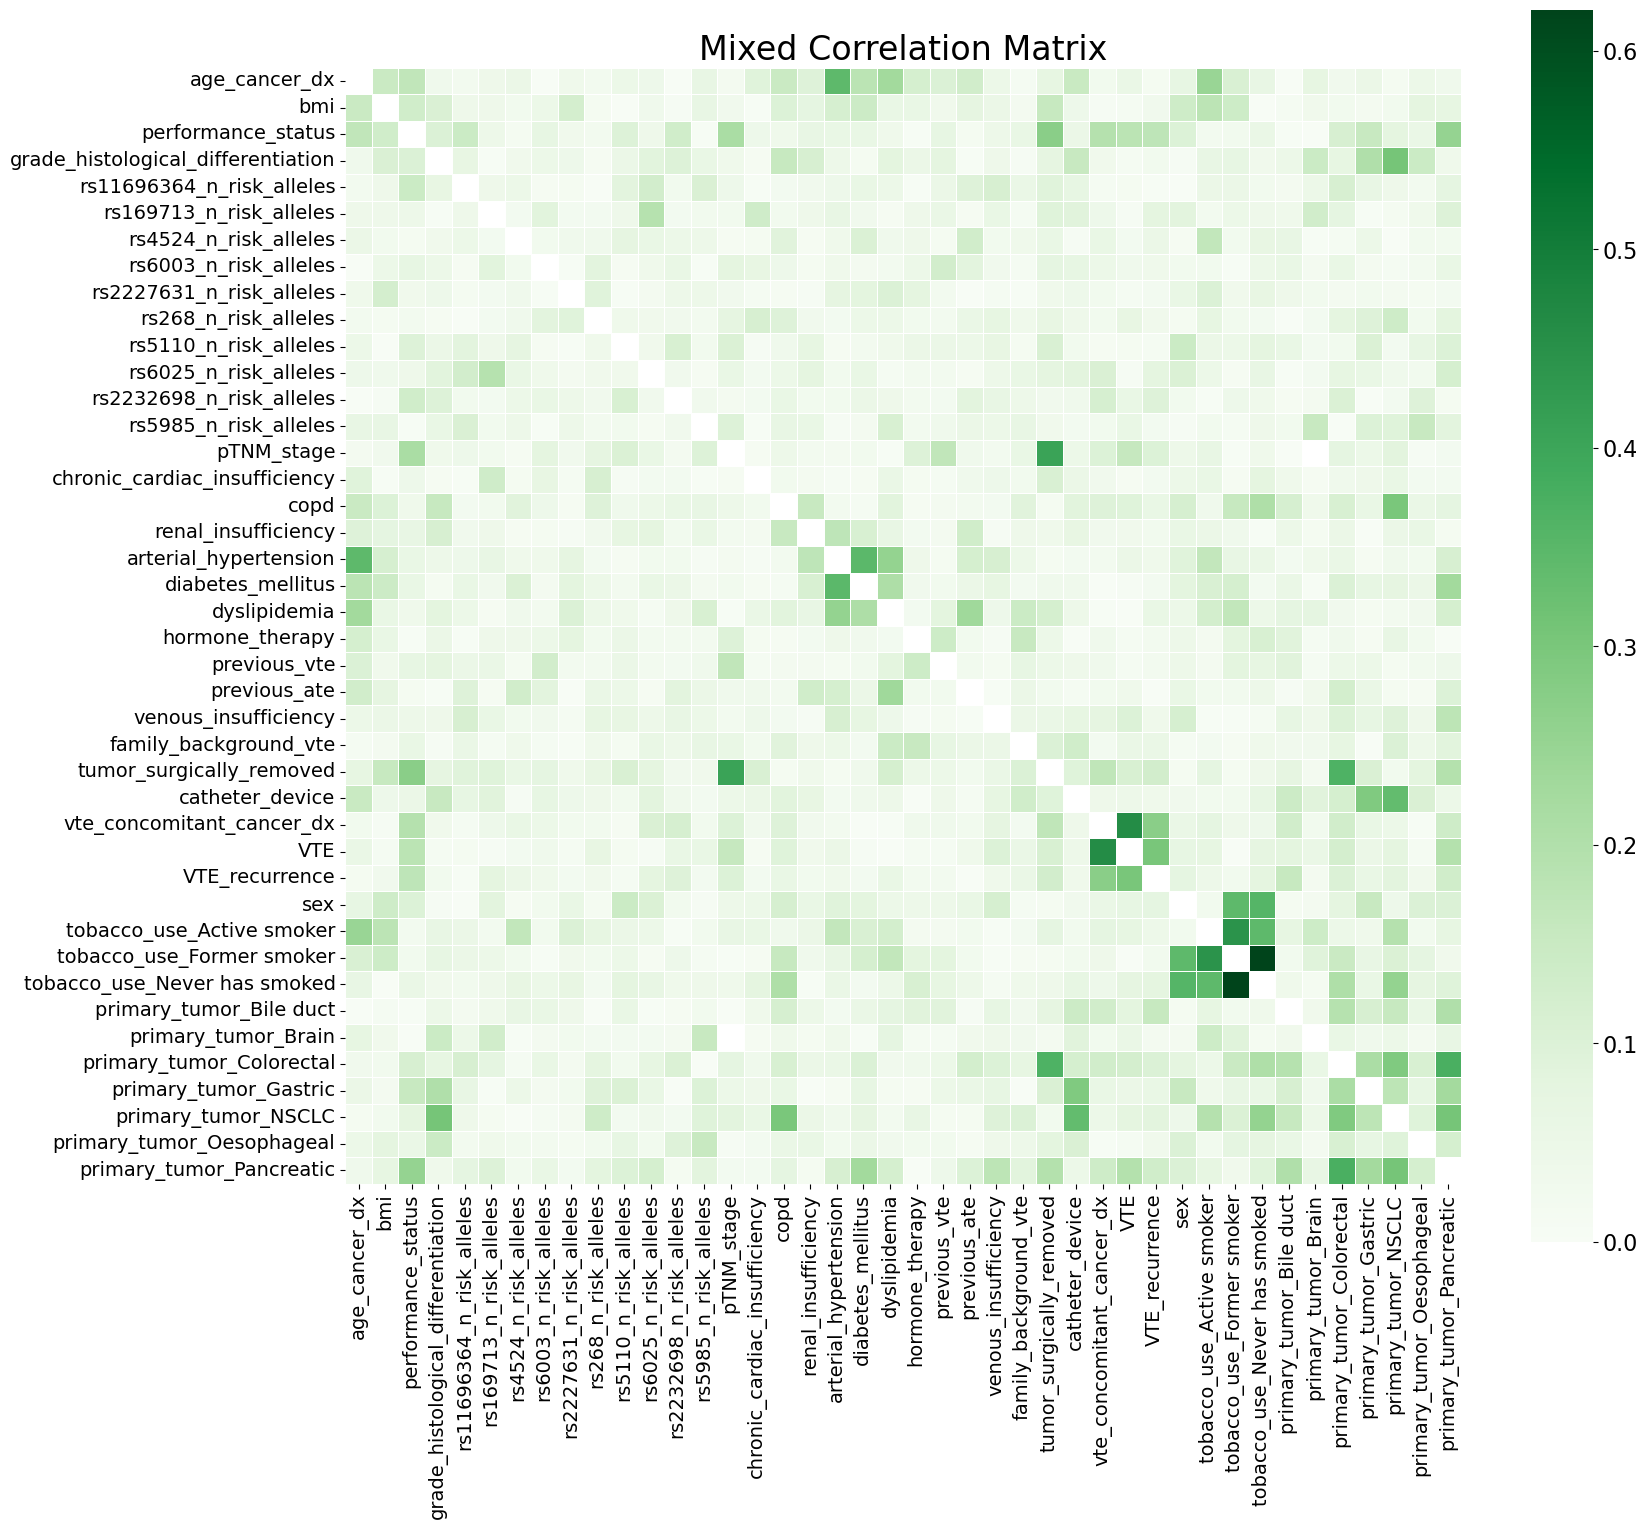

In [37]:
plt.figure(figsize=(18, 16))

ax=sns.heatmap(
    corr_mixed,
    cmap="Greens",     # from white to dark green
    vmin = corr_mixed.min().min(),
    vmax = corr_mixed.max().max(),
    annot=False,
    square=True,
    linewidths=0.5,
    linecolor="white",
    mask=corr_mixed.isna()   # NaN -> also white
)

plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)

plt.title("Mixed Correlation Matrix", fontsize=24)

plt.savefig(
    "images/correlation_matrix_2.png",
    dpi=300,          # high resolution
    bbox_inches="tight"
)

plt.show()

## Save $\texttt{df\_eligible\_reduced2}$ and $\texttt{df\_traits\_reduced2}$ to $\texttt{.csv}$

In [38]:
df_eligible_reduced2.to_csv("dataframes/df_eligible_reduced2.csv", index=False)
df_traits_reduced2.to_csv("dataframes/df_traits_reduced2.csv", index=False)